# Titilt: Enhancing Retail Intelligence: A K-Means++ Approach to Targeted Customer Recommendations

The Business Challenge
Traditional marketing often relies on a "broad-spectrum" approach, delivering the same product advertisements to an entire customer base. This creates two major financial leaks:

Wasted Ad Spend: Marketing high-ticket luxury items to low-income or price-sensitive segments who cannot convert.

Profit Margin Erosion: Offering unnecessary discounts to "high-spending" loyalists who were already prepared to pay full price.

Currently, the business cannot distinguish between a customer who wants to buy but is held back by price, and a customer who can afford to buy but chooses not to spend. This lack of insight results in missed sales opportunities and a poor return on advertising spend (ROAS)
##### The Solution is ML model Recommendation system  here I have choosen Kmeans++ algorithm as the solution for the given problem statement 
K-Means++ Machine Learning model to automatically categorize customers based on their Age, Gender, Annual Income, and Spending Score.

By grouping customers into mathematically precise clusters, the model identifies:`

Target Segments: Exactly which group should receive ads for premium vs. budget-friendly products.

Behavioral Trends: Who is likely to respond to a "value-driven" ad versus an "exclusivity-driven" ad.
The goal is to move from "blind" advertising to Strategic Product Recommendation. By ensuring the right product reaches the right target customer, we maximize the conversion rate and protect the company’s profit margins by eliminating irrelevant ad placements

### Note on Methodology: Multi-Phase Clustering Approach

To ensure both mathematical accuracy and visual interpretability, the model was developed in two strategic phases:

***Phase 1**: Bivariate Visual Analysis – Initially, the model was trained using only two primary features: Annual Income and Spending Score. This was done to create a 2D graphical representation (Scatter Plot), allowing for the visual validation of natural clusters and "elbow point" selection. This phase provides the core business insights regarding customer purchasing power versus actual behavior.

***Phase 2**: High-Dimensional Integration – Following the 2D validation, the model was scaled to include the full feature set (Age, Gender, etc.). This comprehensive approach captures the subtle demographic nuances that drive spending habits, moving beyond simple visualization to a robust, multi-dimensional recommendation engine

### Phase1

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv(r"D:\data sets\Mall_Customers.csv")

In [31]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [32]:
### X split 
X = df[["Annual Income (k$)","Spending Score (1-100)"]]


In [33]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

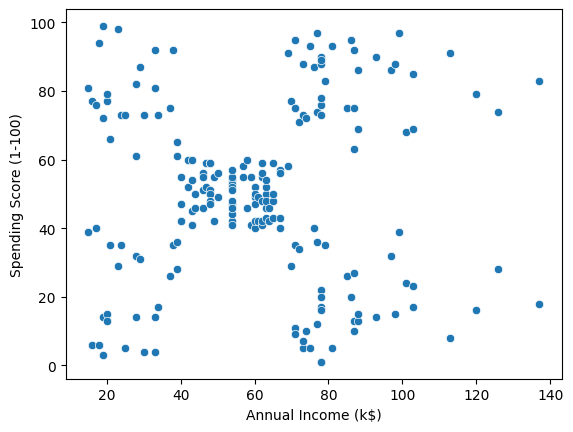

In [34]:
import seaborn as sns
sns.scatterplot(x =df["Annual Income (k$)"],y=df["Spending Score (1-100)"])

### Elbow method

In [35]:
from sklearn.cluster import KMeans

In [36]:
# initializing various values of k for finding the best k
k_values = list(range(1,11))

In [37]:
wcss_list=[]

In [38]:
for each_k in k_values:
    k_means_model = KMeans(n_clusters = each_k)
    k_means_model.fit(X)
    wcss = k_means_model.inertia_
    wcss_list.append(wcss)
    
    

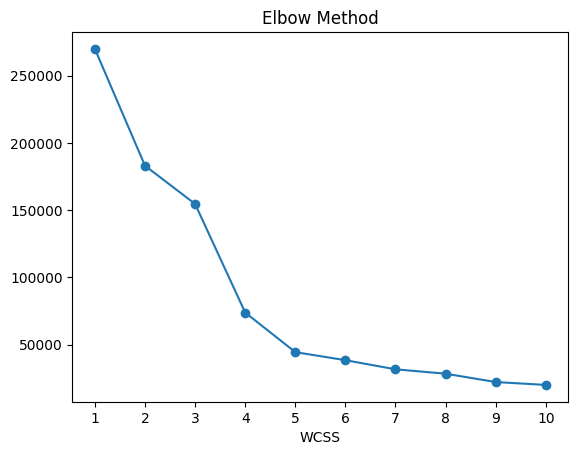

In [39]:
plt.plot(k_values,wcss_list,marker = "o")
plt.xticks(k_values)
plt.xlabel("k_values")
plt.xlabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [40]:
# 5 is optimal clusters

In [41]:
k_means_model =KMeans(n_clusters = 5)


In [42]:
k_means_model.fit(X)

KMeans(n_clusters=5)

In [43]:
clusters = k_means_model.predict(X)

In [44]:
X[clusters ==2]

,Annual Income (k$),Spending Score (1-100)
123,69,91
125,70,77
127,71,95
129,71,75
131,71,75
133,72,71
135,73,88
137,73,73
139,74,72
141,75,93


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

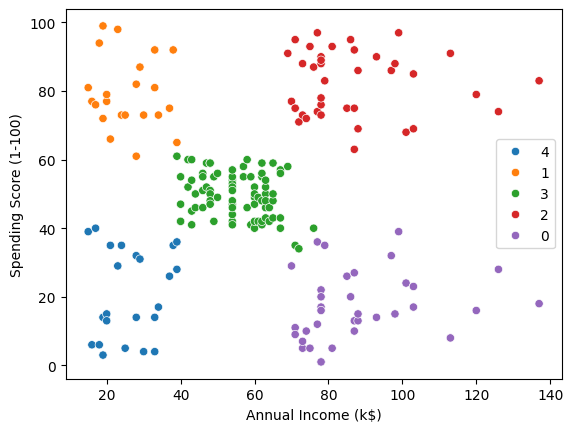

In [45]:
sns.scatterplot(x =X["Annual Income (k$)"],y=X["Spending Score (1-100)"],hue = clusters.astype("str"))

## Observation
Customer Segmentation Insights and Targeting Strategy

Based on clustering analysis of customer income and spending behavior, five distinct customer segments were identified. Each cluster provides valuable insights into purchasing patterns and helps define targeted pricing and marketing strategies.

Blue Cluster – Low Income, Low Spending
Customers in this segment earn between $20,000 and $40,000 and exhibit a low spending score (around 40). Their purchasing behavior is cautious and price-sensitive.
Strategy: Focus on low-priced, value-for-money products and essential offerings to meet their budget constraints while maintaining consistent engagement.

Orange Cluster – Low Income, High Spending
This group has relatively low income but demonstrates a high spending score, indicating strong purchasing motivation despite financial limitations.
Strategy: Target these customers with premium or aspirational products, supported by flexible pricing options, promotions, or bundled offers to sustain their high engagement.

Green Cluster – Income, Moderate Spending
Customers in the green cluster have average income levels and average spending scores, representing a balanced and stable customer base.
Strategy: Offer mid-range priced products that emphasize quality and value, as this segment responds well to balanced pricing and consistent product performance.

Red Cluster – High Income, High Spending
This segment consists of customers with high income and high spending scores, making them the most valuable customers.
Strategy: Focus on high-priced, premium products, exclusive offers, and personalized experiences to maximize revenue and strengthen brand loyalty.

Purple Cluster – High Income, Low Spending
Customers in this group have high income but a low spending score, suggesting underutilized purchasing potential.
Strategy: Promote lower-priced products initially, complemented by discounts, loyalty programs, and targeted promotions to encourage increased spending and deeper engagement.

In [46]:
k_means_model.cluster_centers_[:,1]

array([17.11428571, 79.36363636, 82.12820513, 49.51851852, 20.91304348])

### Plot showing centroid in the clusters

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

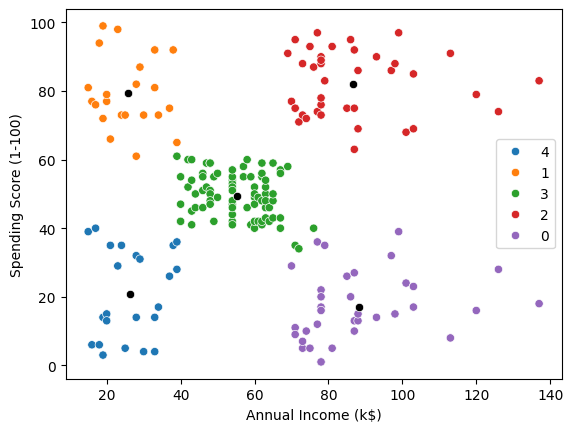

In [47]:
sns.scatterplot(x =X["Annual Income (k$)"],y=X["Spending Score (1-100)"],hue = clusters.astype("str"))
sns.scatterplot(x =k_means_model.cluster_centers_[:,0],y=k_means_model.cluster_centers_[:,1],color='black')

### Phase 2

In [48]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True, dtype=int)

In [49]:
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


In [50]:
x= df

In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(x)

In [53]:
k_means_model =KMeans(n_clusters = 5)


In [54]:
k_means_model.fit(x)

KMeans(n_clusters=5)

### Real time prediction 

In [57]:
customer_id = 1200
age =32
annual_income = 100
spending_score = 80
gender = 1

In [59]:
data = [[customer_id,age,annual_income,spending_score,gender]]


In [60]:
k_means_model.predict(data)

C:\Users\deshp\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

In [61]:
clusters = k_means_model.predict(x)

In [62]:
x[clusters ==2]

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
145,146,28,77,97,1
147,148,32,77,74,0
149,150,34,78,90,1
151,152,39,78,88,1
153,154,38,78,76,0
155,156,27,78,89,0
157,158,30,78,78,0
159,160,30,78,73,0
160,161,56,79,35,0
161,162,29,79,83,0


In [66]:
# Assuming 'result' is your dataframe with the 'Cluster' column
cluster_2_stats = x[clusters ==2].describe()
print(cluster_2_stats.loc['mean'])

CustomerID                175.916667
Age                        36.562500
Annual Income (k$)         94.541667
Spending Score (1-100)     56.333333
Gender_Male                 0.458333
Name: mean, dtype: float64


In [ ]:
## Means we can recommend high price products 

Observation: 
Red Cluster – High Income, High Spending
This segment consists of customers with high income and high spending scores, making them the most valuable customers.
Strategy: Focus on high-priced, premium products, exclusive offers, and personalized experiences to maximize revenue and strengthen brand loyalty.
